# Quick look at the run output

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cmocean import cm
import warnings

warnings.simplefilter('ignore')

In [2]:
# booleans describing the different regions of analysis
def booleans(mydata,region):

    depth_bool = (mydata.deptht>40) & (mydata.deptht<60)

    # region can be jdf, pug (puget sound), nsg (northern SoG), and csg (central SoG)
    # based on boxes on map
    if region == 'jdf':
        y_bool = (mydata.y >=310) & (mydata.y <360)
        x_bool = (mydata.x >=50) & (mydata.x<100)
    
    elif region == 'pug':
        y_bool = (mydata.y >=80) & (mydata.y <130)
        x_bool = (mydata.x >=220) & (mydata.x<270)

    elif region == 'nsg':
        y_bool = (mydata.y >=650) & (mydata.y <700)
        x_bool = (mydata.x >=130) & (mydata.x<180)

    elif region == 'csg':
        y_bool = (mydata.y >=460) & (mydata.y <510)
        x_bool = (mydata.x >=240) & (mydata.x<290)

    else:
        print("invalid region name")

    return depth_bool, y_bool, x_bool

In [4]:
# new files
path = Path("/home/rbeutel/projects/def-allen/rbeutel/MEOPAR/results/AllChange/spinup/")
change =xr.open_mfdataset(sorted(path.glob(f"SalishSea_1d_20180101_20181231_grid_T_2018*.nc")))

# original salishseacast - maybe not worth it since so little is loaded on fir
path = Path("/home/rbeutel/projects/def-allen/SalishSea/nowcast-green.202111/")
old =xr.open_mfdataset(sorted(path.glob(f"*18/SalishSea_1d_*_grid_T.nc")))

In [5]:
change

<xarray.Dataset> Size: 89GB
Dimensions:               (time_counter: 365, y: 898, x: 398, nvertex: 4,
                           deptht: 40, axis_nbounds: 2)
Coordinates:
  * time_counter          (time_counter) datetime64[ns] 3kB 2018-01-01T12:00:...
    time_centered         (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat               (y, x) float32 1MB dask.array<chunksize=(898, 398), meta=np.ndarray>
    nav_lon               (y, x) float32 1MB dask.array<chunksize=(898, 398), meta=np.ndarray>
  * deptht                (deptht) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (time_counter, y, x, nvertex) float32 2GB dask.array<chunksize=(1, 898, 398, 4), meta=np.ndarray>
    bounds_nav_lat        (time_counter, y, x, nvertex) float32 2GB dask.array<chunksize=(1, 898, 398, 4), meta=np.ndarray>
    area                  (time_counter, y, x) float32 522MB dask.array<chunksize=(1, 898, 398), meta=np.ndarray>
    deptht_bounds         (time_counter, deptht, axis_nbounds) float32 117kB dask.array<chunksize=(1, 40, 2), meta=np.ndarray>
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 6kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 6kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    sossheig              (time_counter, y, x) float32 522MB dask.array<chunksize=(1, 898, 398), meta=np.ndarray>
    votemper              (time_counter, deptht, y, x) float32 21GB dask.array<chunksize=(1, 40, 898, 398), meta=np.ndarray>
    vosaline              (time_counter, deptht, y, x) float32 21GB dask.array<chunksize=(1, 40, 898, 398), meta=np.ndarray>
    sigma_theta           (time_counter, deptht, y, x) float32 21GB dask.array<chunksize=(1, 40, 898, 398), meta=np.ndarray>
    e3t                   (time_counter, deptht, y, x) float32 21GB dask.array<chunksize=(1, 40, 898, 398), meta=np.ndarray>
Attributes:
    name:         SalishSea_1d_20180101_20181231_grid_T
    description:  physics tracers and VVL layer thicknesses
    title:        physics tracers and VVL layer thicknesses
    Conventions:  CF-1.6
    timeStamp:    2026-Jun-26 04:54:52 GMT
    uuid:         87e5ba95-390f-4dcc-8316-662e059ca344

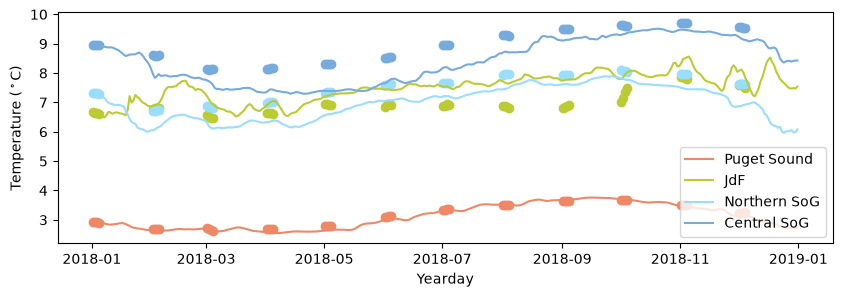

In [6]:
fig, ax = plt.subplots(1,1,figsize=(10,3))

depth_bool, y_bool, x_bool = booleans(change,'pug')
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',label='Puget Sound')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866')

depth_bool, y_bool, x_bool = booleans(change,'jdf')
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',label='JdF')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33')

depth_bool, y_bool, x_bool = booleans(change,'nsg')
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',label='Northern SoG')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF')

depth_bool, y_bool, x_bool = booleans(change,'csg')
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',label='Central SoG')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD')

ax.set_ylabel('Temperature ($^\circ$C)')
ax.set_xlabel('Yearday')
ax.legend()

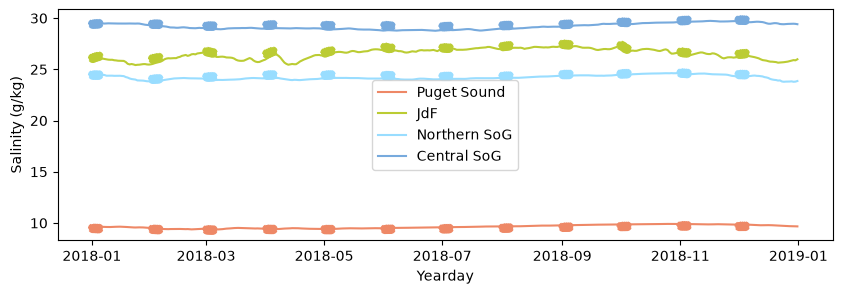

In [7]:
fig, ax = plt.subplots(1,1,figsize=(10,3))

depth_bool, y_bool, x_bool = booleans(change,'pug')
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',label='Puget Sound')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'jdf')
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',label='JdF')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'nsg')
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',label='Northern SoG')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'csg')
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',label='Central SoG')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',ls='dashed')

ax.set_ylabel('Salinity (g/kg)')
ax.set_xlabel('Yearday')
ax.legend()

In [14]:
# new files
path = Path("/home/rbeutel/projects/def-allen/rbeutel/MEOPAR/results/AllChange/spinup/")
change =xr.open_mfdataset(sorted(path.glob(f"SalishSea_1d_20180101_20181231_chem_T_*.nc")))

# original salishseacast - maybe not worth it since so little is loaded on fir
path = Path("/home/rbeutel/projects/def-allen/SalishSea/nowcast-green.202111/")
old =xr.open_mfdataset(sorted(path.glob(f"*18/SalishSea_1d_*_chem_T.nc")))

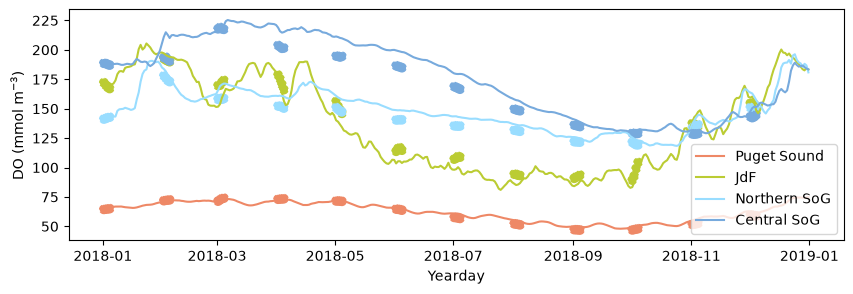

In [15]:
fig, ax = plt.subplots(1,1,figsize=(10,3))

depth_bool, y_bool, x_bool = booleans(change,'pug')
ax.plot(change.time_counter,np.mean(change.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',label='Puget Sound')
ax.scatter(old.time_counter,np.mean(old.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'jdf')
ax.plot(change.time_counter,np.mean(change.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',label='JdF')
ax.scatter(old.time_counter,np.mean(old.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'nsg')
ax.plot(change.time_counter,np.mean(change.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',label='Northern SoG')
ax.scatter(old.time_counter,np.mean(old.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'csg')
ax.plot(change.time_counter,np.mean(change.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',label='Central SoG')
ax.scatter(old.time_counter,np.mean(old.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',ls='dashed')

ax.set_ylabel('DO (mmol m$^{-3}$)')
ax.set_xlabel('Yearday')
ax.legend()

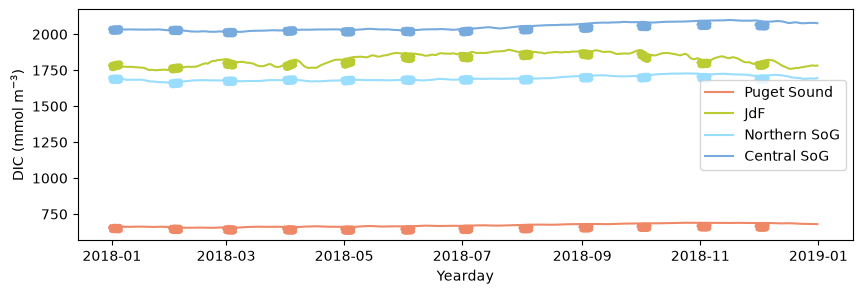

In [16]:
fig, ax = plt.subplots(1,1,figsize=(10,3))

depth_bool, y_bool, x_bool = booleans(change,'pug')
ax.plot(change.time_counter,np.mean(change.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',label='Puget Sound')
ax.scatter(old.time_counter,np.mean(old.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'jdf')
ax.plot(change.time_counter,np.mean(change.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',label='JdF')
ax.scatter(old.time_counter,np.mean(old.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'nsg')
ax.plot(change.time_counter,np.mean(change.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',label='Northern SoG')
ax.scatter(old.time_counter,np.mean(old.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'csg')
ax.plot(change.time_counter,np.mean(change.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',label='Central SoG')
ax.scatter(old.time_counter,np.mean(old.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',ls='dashed')

ax.set_ylabel('DIC (mmol m$^{-3}$)')
ax.set_xlabel('Yearday')
ax.legend()

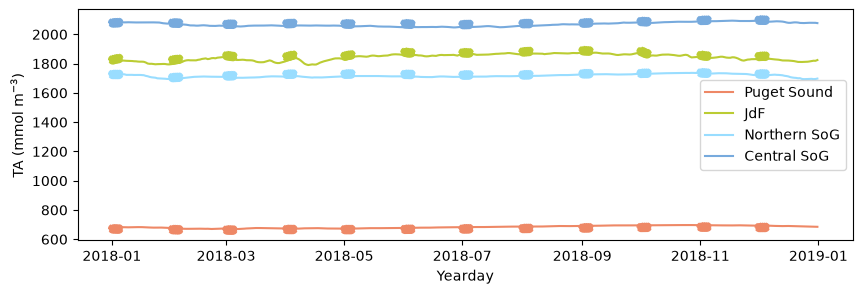

In [17]:
fig, ax = plt.subplots(1,1,figsize=(10,3))

depth_bool, y_bool, x_bool = booleans(change,'pug')
ax.plot(change.time_counter,np.mean(change.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',label='Puget Sound')
ax.scatter(old.time_counter,np.mean(old.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'jdf')
ax.plot(change.time_counter,np.mean(change.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',label='JdF')
ax.scatter(old.time_counter,np.mean(old.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'nsg')
ax.plot(change.time_counter,np.mean(change.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',label='Northern SoG')
ax.scatter(old.time_counter,np.mean(old.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'csg')
ax.plot(change.time_counter,np.mean(change.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',label='Central SoG')
ax.scatter(old.time_counter,np.mean(old.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',ls='dashed')

ax.set_ylabel('TA (mmol m$^{-3}$)')
ax.set_xlabel('Yearday')
ax.legend()

In [18]:
# new files
path = Path("/home/rbeutel/projects/def-allen/rbeutel/MEOPAR/results/AllChange/spinup/")
change =xr.open_mfdataset(sorted(path.glob(f"SalishSea_1d_20180101_20181231_biol_T_*.nc")))

# original salishseacast - maybe not worth it since so little is loaded on fir
path = Path("/home/rbeutel/projects/def-allen/SalishSea/nowcast-green.202111/")
old =xr.open_mfdataset(sorted(path.glob(f"*18/SalishSea_1d_*_biol_T.nc")))

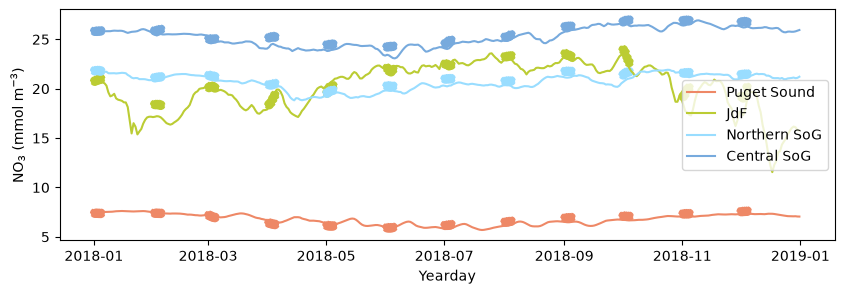

In [19]:
fig, ax = plt.subplots(1,1,figsize=(10,3))

depth_bool, y_bool, x_bool = booleans(change,'pug')
ax.plot(change.time_counter,np.mean(change.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',label='Puget Sound')
ax.scatter(old.time_counter,np.mean(old.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'jdf')
ax.plot(change.time_counter,np.mean(change.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',label='JdF')
ax.scatter(old.time_counter,np.mean(old.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'nsg')
ax.plot(change.time_counter,np.mean(change.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',label='Northern SoG')
ax.scatter(old.time_counter,np.mean(old.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'csg')
ax.plot(change.time_counter,np.mean(change.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',label='Central SoG')
ax.scatter(old.time_counter,np.mean(old.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',ls='dashed')

ax.set_ylabel('NO$_3$ (mmol m$^{-3}$)')
ax.set_xlabel('Yearday')
ax.legend()